In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [3]:
df = pd.read_csv('titanic_toy.csv')

In [4]:
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       714 non-null    float64
 1   Fare      846 non-null    float64
 2   Family    891 non-null    int64  
 3   Survived  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [6]:
df.isnull().mean()

Age         0.198653
Fare        0.050505
Family      0.000000
Survived    0.000000
dtype: float64

In [7]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [9]:
X_train.shape, X_test.shape

((712, 3), (179, 3))

In [10]:
X_train.isnull().mean()

Age       0.198034
Fare      0.054775
Family    0.000000
dtype: float64

In [11]:
mean_age = X_train['Age'].mean()
median_age = X_train['Age'].median()

mean_fare = X_train['Fare'].mean()
median_fare = X_train['Fare'].median()

In [12]:
X_train['Age_median'] = X_train['Age'].fillna(median_age)
X_train['Age_mean'] = X_train['Age'].fillna(mean_age)

X_train['Fare_median'] = X_train['Fare'].fillna(median_fare)
X_train['Fare_mean'] = X_train['Fare'].fillna(mean_fare)

In [13]:
X_train.sample(5)

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
491,21.0,7.2500,0,21.0,21.000000,7.2500,7.2500
825,NaN,6.9500,0,29.0,29.745184,6.9500,6.9500
174,56.0,30.6958,0,56.0,56.000000,30.6958,30.6958
226,19.0,10.5000,0,19.0,19.000000,10.5000,10.5000
504,16.0,86.5000,0,16.0,16.000000,86.5000,86.5000


In [14]:
print('Original Age variable variance: ', X_train['Age'].var())
print('Age Variance after median imputation: ', X_train['Age_median'].var())
print('Age Variance after mean imputation: ', X_train['Age_mean'].var())

print('Original Fare variable variance: ', X_train['Fare'].var())
print('Fare Variance after median imputation: ', X_train['Fare_median'].var())
print('Fare Variance after mean imputation: ', X_train['Fare_mean'].var())

Original Age variable variance:  213.7165085187578
Age Variance after median imputation:  171.42222438960798
Age Variance after mean imputation:  171.33390978297038
Original Fare variable variance:  2574.3526206637193
Fare Variance after median imputation:  2448.897024777755
Fare Variance after mean imputation:  2433.143405184275


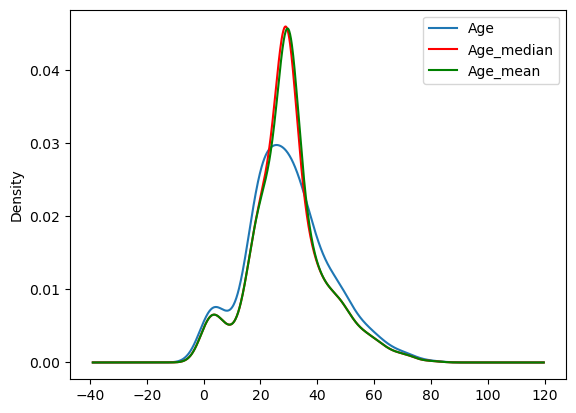

In [15]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution
X_train['Age'].plot(kind='kde', ax=ax)

# variable imputed with the median
X_train['Age_median'].plot(kind='kde', ax=ax, color='red')

# variable imputed with the mean
X_train['Age_mean'].plot(kind='kde', ax=ax, color='green')

# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

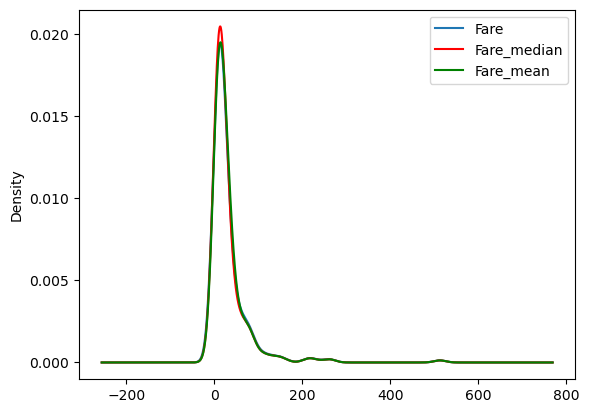

In [16]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution
X_train['Fare'].plot(kind='kde', ax=ax)

# variable imputed with the median
X_train['Fare_median'].plot(kind='kde', ax=ax, color='red')

# variable imputed with the mean
X_train['Fare_mean'].plot(kind='kde', ax=ax, color='green')

# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

In [18]:
X_train.corr()

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
Age,1.000000,0.106334,-0.295318,1.000000,1.000000,0.103346,0.103929
Fare,0.106334,1.000000,0.198661,0.102921,0.101058,1.000000,1.000000
Family,-0.295318,0.198661,1.000000,-0.235021,-0.235270,0.197721,0.196290
Age_median,1.000000,0.102921,-0.235021,1.000000,0.999742,0.100062,0.100620
Age_mean,1.000000,0.101058,-0.235270,0.999742,1.000000,0.098295,0.098800
Fare_median,0.103346,1.000000,0.197721,0.100062,0.098295,1.000000,0.996778
Fare_mean,0.103929,1.000000,0.196290,0.100620,0.098800,0.996778,1.000000


<Axes: >

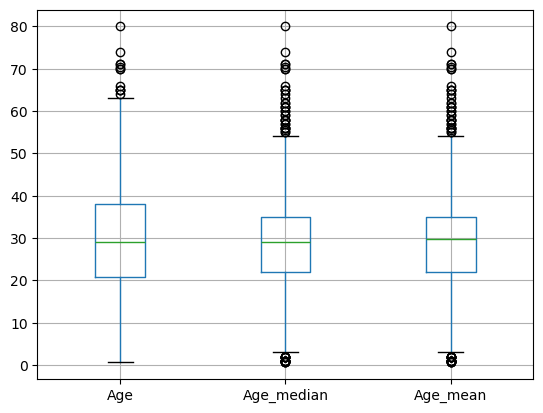

In [19]:
X_train[['Age', 'Age_median', 'Age_mean']].boxplot()

<Axes: >

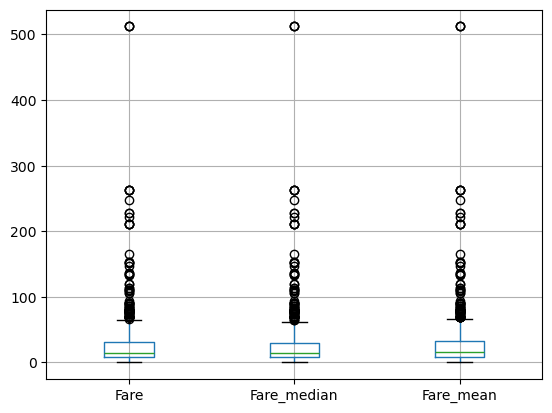

In [20]:
X_train[['Fare', 'Fare_median', 'Fare_mean']].boxplot()

## Using Sklearn

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [22]:
imputer1 = SimpleImputer(strategy = 'median')
imputer2 = SimpleImputer(strategy= 'mean')

In [27]:
trf = ColumnTransformer([
    ('imputer1', imputer1,['Age']),
    ('imputer2', imputer2,['Fare'])
    ], remainder = 'passthrough')

In [28]:
trf.fit(X_train)

c:\Users\Mani\anaconda3\Lib\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


ColumnTransformer(remainder='passthrough',
                  transformers=[('imputer1', SimpleImputer(strategy='median'),
                                 ['Age']),
                                ('imputer2', SimpleImputer(), ['Fare'])])

In [29]:
trf.named_transformers_['imputer1'].statistics_

array([29.])

In [30]:
trf.named_transformers_['imputer2'].statistics_

array([31.88531382])

In [31]:
X_train = trf.transform(X_train)
X_test = trf.transform(X_test)

In [32]:
X_train

array([[29.    , 15.2458,  2.    ],
       [31.    , 10.5   ,  0.    ],
       [31.    , 37.0042,  2.    ],
       ...,
       [29.    ,  7.7333,  0.    ],
       [36.    , 17.4   ,  1.    ],
       [60.    , 39.    ,  2.    ]])